# Post-processing tool tutorial

This example illustrates how to use the framework to postprocess the database mimicking the ercoftac database

In [1]:
import os
import warnings
import json
#
import numpy                    as np
import matplotlib.pyplot        as plt
from matplotlib.ticker          import ScalarFormatter
from  interface                 import PostProcessMusicaa
from ppModule.readExp.ercoftac  import ReadErcoftac

warnings.filterwarnings('ignore')

## 1. Initiate postprocessing object:

In [2]:
# Load configuration file
casename = 't3a'
with open(f'examples/ercoftac/config.json') as json_file:
    config = json.load(json_file)

# Initialize post-processing module
pp = PostProcessMusicaa(config=config[casename]["ppMusicaa"])
#
tauw = pp.compute_qty(qty="tauw")[2]
stats= pp.return_stats()[2]
Ue   = stats["ufst"]
Cf   = stats["cf"]
rex_num = Ue*pp.config["grid"]["x"][2][:,0]*stats["rho_fst"]/pp.info["Muref"]



#### 1.1. Load normalization quantities, for better comparison with experiments:

In [3]:
#
rex_cf_min = config[casename]["rex_cf_min"]
rex_cf_max = config[casename]["rex_cf_max"]
Uin_exp    = config[casename]["Uin_exp"]
Uin_num    = config[casename]["Uin_num"]
# Normalize reynolds number:
rex_norm= (rex_num - rex_cf_min) / (rex_cf_max - rex_cf_min)


#### 1.2. Set up some parameters for figures:

In [4]:
title_size  = 20
label_size  = 20
axis_size   = 18

## 2. Load experimental data:

In [5]:
# Mean data along x-axis
mean_data = ReadErcoftac.read_summary_file_to_dict(filename=os.path.join(config[casename]["exp_path"], "summary.txt"))
rex_exp   = [(mean_data["REX"][i] - rex_cf_min) / (rex_cf_max - rex_cf_min) for i in range(len(mean_data["REX"]))]
#


## 3. Post-process results

For the T3C- cases, plot the freestream velocity normalized by the inlet velocity to comare with experiments:

In [6]:
def contains_substring(string, substring):
    return substring in string
#
if contains_substring(casename.upper(), "T3C"):
    plt.figure(figsize=(8,6))
    plt.plot(rex_norm, Ue/Uin_num, color="black", linewidth=2.5)
    plt.scatter(rex_exp, np.array(mean_data["UO"])/Uin_exp, color="red", s=50, marker="o", label="Exp. data")
    plt.xlabel(r"$\frac{Re_x - Re_x(C_{f,min})}{Re_x(C_{f,max}) - Re_x(C_{f,min})}$"   , fontsize=22)
    plt.ylabel(r"$U_e$", fontsize=label_size)
    plt.tick_params(axis="both", which="major", labelsize=axis_size)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    plt.gca().xaxis.get_offset_text().set_fontsize(16)
    plt.legend()
    plt.xlim(left=-0.7, right=1.75) # Adjust for each case
    plt.tight_layout()
    

Plot the skin friction coefficient:

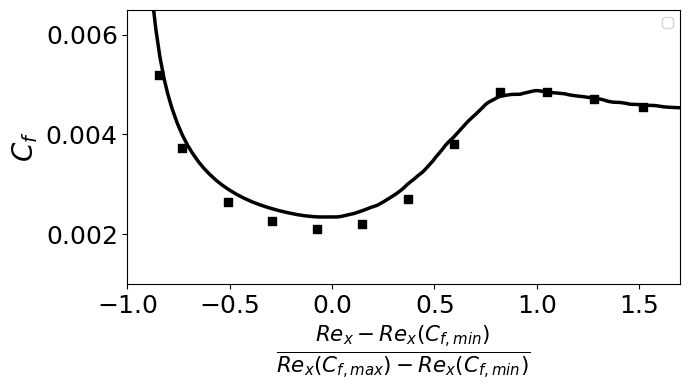

In [7]:
plt.figure(figsize=(7,4))
plt.plot(rex_norm[:-50], Cf[:-50], color="black", linewidth=2.5)
plt.scatter(rex_exp, mean_data["CF"], color="black", marker="s")
plt.xlabel(r"$\frac{Re_x - Re_x(C_{f,min})}{Re_x(C_{f,max}) - Re_x(C_{f,min})}$", fontsize=22)
plt.ylabel(r"$C_f$", fontsize=label_size)
plt.tick_params(axis="both", which="major", labelsize= axis_size)
plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis="x", scilimits=(0, 0))
plt.gca().xaxis.get_offset_text().set_fontsize(16)
plt.ylim(0.001, 0.0065) # Adjust for each case  
plt.xlim(left=-1, right=1.7) # Adjust for each casess
plt.legend()
plt.tight_layout()
